In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

from matplotlib import pyplot as plt
import numpy as np
from equayes import Equayes, PROJECT_ROOT
from equayes.core.pyro_backend import utils as pyro_utils
from equayes.visualisation import predictive_plotting as pred_plot
from equayes.core.sympy_backend import utils as sp_utils

import sympy as sp
import torch
import os
import arviz as az
import torch
import pandas as pd
import xarray
import seaborn as sns

In [3]:
import matplotlib as mpl

font_size_small = 12
font_size_big = 14

mpl.rcParams["legend.fontsize"] = font_size_big  # legend labels
mpl.rcParams["axes.labelsize"] = font_size_big  # x/y axis labels
mpl.rcParams["xtick.labelsize"] = font_size_small  # x tick labels
mpl.rcParams["ytick.labelsize"] = font_size_small

Text(0, 0.5, 'y')

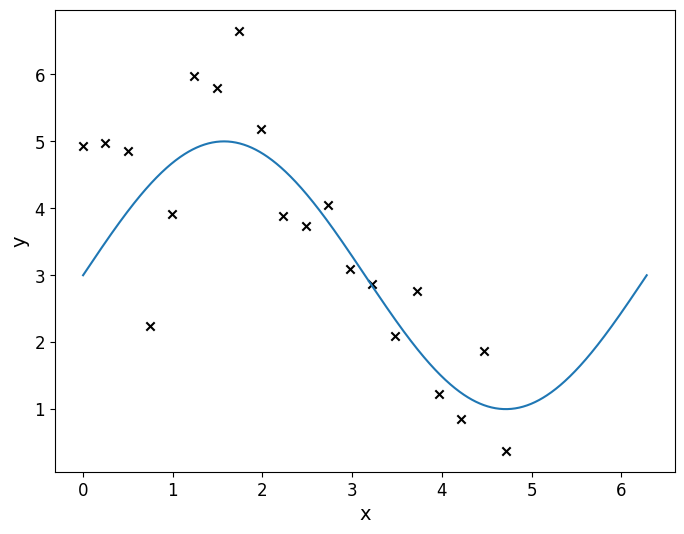

In [4]:
# create data
N_train = 20
N_test = 1000
seed = 42

noise_sigma = 1.0
np.random.seed(seed)
torch.manual_seed(seed)


def synthetic_function_1d(x, noise_sigma=1.0):
    y = 2 * torch.sin(x) + 3
    y_obs = y + torch.randn(x.shape if len(x) > 0 else (1,)) * noise_sigma
    return y, y_obs


x_train = torch.linspace(0, 3 * np.pi / 2, steps=N_train)
x_test = torch.linspace(0, 4 * np.pi / 2, steps=N_test)
# scale x (0,2pi) --> (-1,1) for numerical stability
x_train_scaled = x_train / torch.pi - 1.0
x_test_scaled = x_test / torch.pi - 1.0
y_train, y_obs_train = synthetic_function_1d(x_train, noise_sigma)
y_test, y_obs_test = synthetic_function_1d(x_test, noise_sigma)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.scatter(x_train, y_obs_train, marker="x", color="black")
plt.plot(x_test, y_test, label="True Function")
plt.xlabel("x")
plt.ylabel("y")

In [5]:
# define sympy expression
x0 = sp.Symbol("x0")

expr_sp_true = 2.0 * sp.sin(x0) + 3.0
expr_sp_quadratic = 2.0 * x0**2 - 1.1 * x0 + 5.0

polynomial_degree = 3
expr_polynomial = 1.0
for i in range(1, polynomial_degree + 1):
    expr_polynomial = np.random.rand() * 1 / (2 * i) * x0**i + expr_polynomial
print(expr_polynomial)

selected_expression = expr_polynomial

0.121998990301901*x0**3 + 0.237678576602479*x0**2 + 0.187270059423681*x0 + 1.0


tensor(15.1074, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
tensor(0.8561, grad_fn=<MseLossBackward0>)
p0*x0**3 + p1*x0**2 + p2*x0 + p3
p0 tensor(2.2889)
p1 tensor(-1.7255)
p2 tensor(-5.0203)
p3 tensor(3.1692)


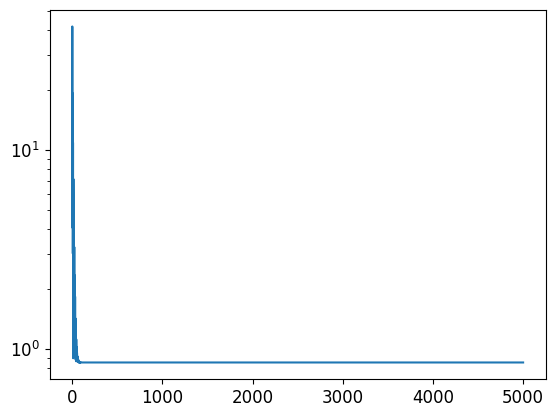

In [ ]:
# deterministic fit

np.random.seed(seed)
torch.manual_seed(seed)
expr_sp_parameterized, exp_param_values = sp_utils.replace_floats_in_print_order(selected_expression)
expr_torch_with_params = sp.lambdify([x0] + list(exp_param_values.keys()), expr_sp_parameterized, modules=["torch"])

# learnable torch parameters
params = torch.nn.ParameterList([torch.nn.Parameter(torch.randn(())) for _ in range(len(exp_param_values))])

# gradient descent MLE fit
n_iter = 7000
lr = 5e-1
lrd = 1e-2
optim = torch.optim.Adam(params, lr=lr)
loss_function = torch.nn.MSELoss()
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, gamma=lrd ** (1 / n_iter))
losses = []
for i in range(n_iter):
    optim.zero_grad()

    y_pred = expr_torch_with_params(x_train_scaled, *params)
    loss = loss_function(y_pred, y_obs_train)

    loss.backward()
    optim.step()
    lr_scheduler.step()
    losses.append(loss.detach())
    if i % 500 == 0:
        print(loss)

plt.plot(np.linspace(0, n_iter, n_iter), torch.tensor(losses))
plt.yscale("log")

print(expr_sp_parameterized)
for i, latent_var in enumerate(list(exp_param_values.keys())):
    print(latent_var, params[i].detach())

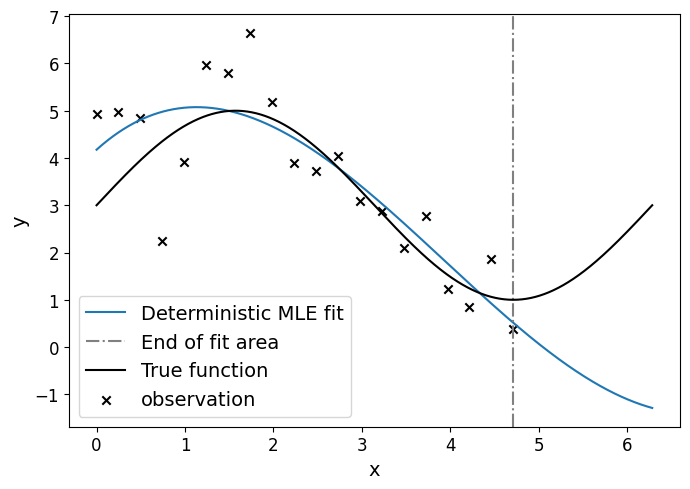

In [7]:
# eval deterministic fit
y_pred_test = expr_torch_with_params(x_test_scaled, *params).detach()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(x_test, y_pred_test, label="Deterministic MLE fit")
ax.axvline(3 / 2 * np.pi, linestyle="-.", color="grey", label="End of fit area")
ax.plot(x_test, y_test, label="True function", color="black")
ax.scatter(x_train, y_obs_train, marker="x", color="black", label="observation")
ax.legend()
# ax.set_xlim(0,3/2 *np.pi)
# ax.set_ylim(-20, 20)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
os.makedirs(f"{PROJECT_ROOT}/output/", exist_ok=True)
plt.savefig(f"{PROJECT_ROOT}/output/degree_{polynomial_degree}_prediction_deterministic.png")

In [8]:
expr_polynomial_from_det_solution = 0.0
if str(expr_sp_parameterized).startswith(("(-", "-")):
    expr_polynomial_from_det_solution = -params[0] * x0 ** (polynomial_degree)
else:
    expr_polynomial_from_det_solution = params[0] * x0 ** (polynomial_degree)
for i in range(1, polynomial_degree + 1):
    expr_polynomial_from_det_solution = params[i] * x0 ** (polynomial_degree - i) + expr_polynomial_from_det_solution

print(expr_polynomial_from_det_solution)

2.28889226913452*x0**3 - 1.72548174858093*x0**2 - 5.02031183242798*x0 + 3.16915082931519


In [9]:
equayes = Equayes(
    expr=expr_polynomial_from_det_solution,
    input_symbols=[x0],
    output_dim=1,
    jit_compile=True,
    # available params with default settings
    # inference_method_name="mcmc",
    # kernel_name="nuts",
    # mcmc_warmup_samples=1500,
    # mcmc_samples=2000,
    # vi_iter=3000,
    # vi_lr=1e-2,
    # vi_lrd=1e0,
)
print(equayes.expr_sp)
print(equayes._expr_sp_parameterized)

losses_optional = equayes.fit(x_train_scaled.view((-1, 1)), y_obs_train.view((-1, 1)))
if losses_optional is not None:
    plt.plot(np.linspace(0, equayes.vi_iter, equayes.vi_iter), losses_optional)
    plt.yscale("log")

2.28889226913452*x0**3 - 1.72548174858093*x0**2 - 5.02031183242798*x0 + 3.16915082931519
p0*x0**3 - p1*x0**2 - p2*x0 + p3


Sample: 100%|██████████| 3500/3500 [05:45, 10.14it/s, step size=1.25e-01, acc. prob=0.934]


In [10]:
if losses_optional is not None:  # used, if variational inference is used. (equayes.inference_method_name = "vi")
    plt.plot(np.linspace(0, equayes.vi_iter, equayes.vi_iter), losses_optional)
    plt.yscale("symlog")
    plt.ylim(torch.tensor(losses_optional).min() * 0.5, 1e4)

In [11]:
equayes.predict(x_train.view((-1, 1)), sample_prior=False, parallel=True)["mu"].shape

torch.Size([500, 1, 20, 1])

In [12]:
# Evaluation

os.makedirs(f"{PROJECT_ROOT}/output", exist_ok=True)

equayes.inference_diagnostics()

inference_dt = equayes.get_posterior()
if type(inference_dt) is not xarray.DataTree:
    inference_dt = pyro_utils.guide_to_inference_data(
        equayes._pyro_model, equayes._guide, x_train.view((-1, 1)), num_samples=3000
    )

# az.plot_trace(inference_dt)
plt.tight_layout()
plt.savefig(
    f"{PROJECT_ROOT}/output/degree_{polynomial_degree}_posterior_{equayes.inference_method_name}_{equayes.kernel_name}.png"
)
#


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
 epsilon[0]      1.07      0.20      1.04      0.76      1.36    931.89      1.00
theta_p0[0]      2.34      3.32      2.44     -2.90      7.45    533.77      1.00
theta_p1[0]      1.66      2.81      1.63     -2.73      6.26    525.84      1.00
theta_p2[0]      5.00      1.02      5.05      3.32      6.56    854.09      1.00
theta_p3[0]      3.17      0.42      3.16      2.51      3.87    723.22      1.00

Number of divergences: 0


<Figure size 640x480 with 0 Axes>

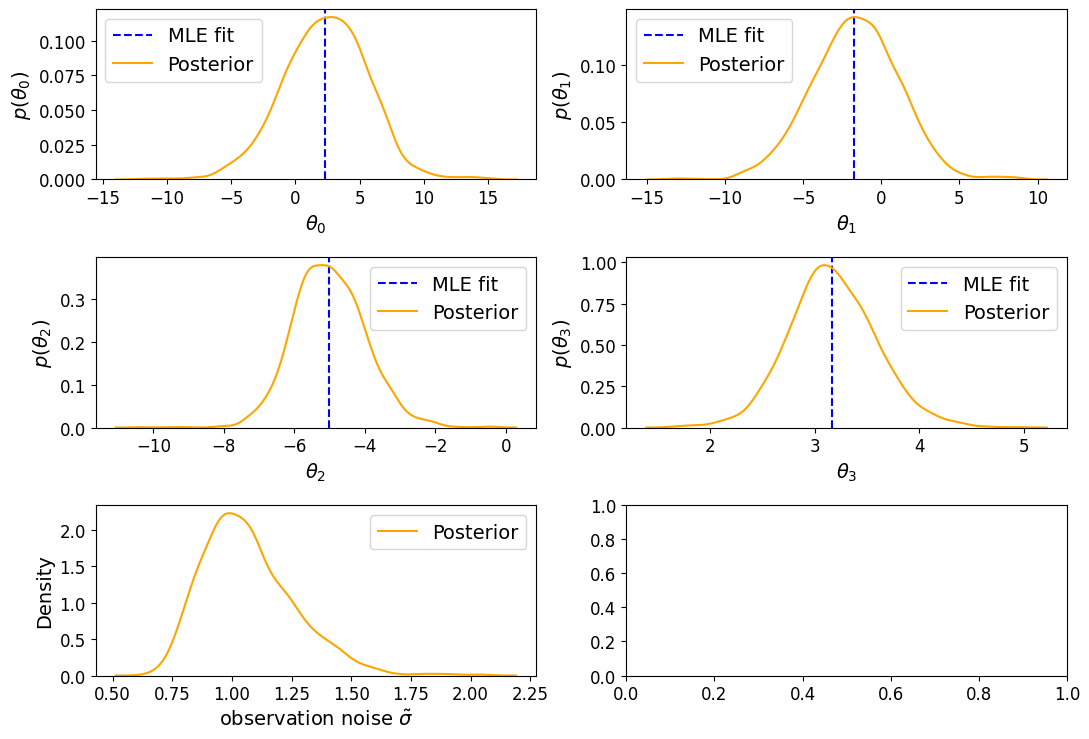

In [13]:
fig, axs = plt.subplots(
    int(np.ceil((polynomial_degree + 3) / 2.0)),
    2,
    figsize=(11, (polynomial_degree + 3) // 2.0 * 2.5),
)
for i in range(polynomial_degree + 1):
    axs[i // 2, i % 2].axvline(params[i].detach().numpy(), color="blue", linestyle="--", label="MLE fit")
    # if mle fit param is negative, the posterior must be negated due to sign conventions
    post_vals = inference_dt["posterior"][f"theta_p{i}"].values.flatten()
    if params[i] < 0:
        post_vals = -post_vals
    sns.kdeplot(post_vals, ax=axs[i // 2, i % 2], label="Posterior", color="orange")
    # axs[i // 2, i % 2].set_xlabel(rf"$\theta_{i}$ (coefficient of: $x^{3-i}$)")
    axs[i // 2, i % 2].set_xlabel(rf"$\theta_{i}$")
    axs[i // 2, i % 2].set_ylabel(rf"$p(\theta_{i})$")
    axs[i // 2, i % 2].legend(loc="best")
sns.kdeplot(
    inference_dt["posterior"]["epsilon"].values.flatten(),
    ax=axs[-1, 0],
    label="Posterior",
    color="orange",
)
axs[-1, 0].set_xlabel(rf"observation noise $\tilde{{\sigma}}$")
axs[-1, 0].legend()
# axs[-1,-1].axis("off")

# plot correlation matrix
if equayes.inference_method_name == "vi":
    posterior = equayes._guide.get_posterior()
    cov = posterior.covariance_matrix.detach().cpu()

    # Convert to correlation matrix
    std = torch.sqrt(torch.diag(cov))
    corr = cov / (std[:, None] * std[None, :])

    # labels = [r"$\theta_0$", r"$\theta_1$", r"$\theta_2$", r"$\theta_3$", r"$\epsilon$"]
    labels = [rf"$\theta_{i}$" for i in range(polynomial_degree + 1)]
    labels.append(r"$\epsilon$")
    corr_df = pd.DataFrame(corr.numpy(), index=labels, columns=labels)
    sns.heatmap(
        corr_df,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        square=False,
        cbar=True,
        ax=axs[-1, -1],
    )
# axs[-1,-1].set_aspect("equal")
# axs[-1,-1].set_xticklabels(axs[-1,-1].get_xticklabels(), rotation=0, ha='center')
# axs[-1,-1].set_yticklabels(axs[-1,-1].get_yticklabels(), rotation=0, va='center')

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/output/degree_{polynomial_degree}_posterior.png")

torch.Size([500, 1, 1000, 1])


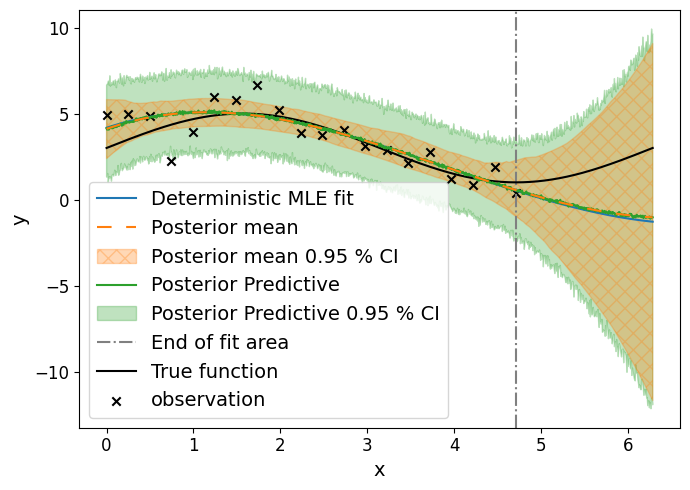

In [14]:
pred_samples = equayes.predict(x_test_scaled.view(-1, 1), n_predictive_samples=500, parallel=True)
print(pred_samples["mu"].shape)
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.plot(x_test, y_pred_test, label="Deterministic MLE fit")
ax = pred_plot.plot_1d_predictive_density(
    x_test.numpy(),
    pred_samples["mu"].squeeze().numpy(),
    ci=0.95,
    label="Posterior mean",
    zorder=1,
    linestyle=(0, (7, 7)),
    hatch="xx",
    ax=ax,
)
ax = pred_plot.plot_1d_predictive_density(
    x_test.numpy(),
    pred_samples["obs"].squeeze().numpy(),
    ci=0.95,
    label="Posterior Predictive",
    zorder=0,
    ax=ax,
)
ax.axvline(3 / 2 * np.pi, linestyle="-.", color="grey", label="End of fit area")

ax.plot(x_test, y_test, label="True function", color="black")
ax.scatter(x_train, y_obs_train, marker="x", color="black", label="observation")
ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_ylim((-2.5, 18))
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{PROJECT_ROOT}/output/degree_{polynomial_degree}_post_pred_{equayes.inference_method_name}_{equayes.kernel_name}.png"
)